In [1]:
import sys
sys.path.append('../')
from utils_models import *

dq.set_device('cpu')

2024-03-25 00:55:07.167923: E external/xla/xla/stream_executor/cuda/cuda_driver.cc:282] failed call to cuInit: UNKNOWN ERROR (100)


In [2]:
amp_with_2pi = 0.011026707187734986
flux = 0.40367803977430805
pulse_length = 308.37376398206834-6

t_rise = 30
t_tot = t_rise + pulse_length

tlist = np.linspace(0,t_tot,int(t_tot))
t_tot

332.37376398206834

In [3]:
fluxonium = scqubits.Fluxonium(EJ=2.7,
                        EC=0.6,
                        EL=0.13,
                        flux=0,cutoff=110,
                        truncated_dim=20)
tune_tmon = scqubits.TunableTransmon(
    EJmax=50,
    EC=0.5,
    d=0.01,
    flux=flux,
    ng=0.0,
    ncut=30,
    truncated_dim = 4
    )
system = FluxoniumTunableTransmonSystem(
    fluxonium  = fluxonium,
    tune_tmon = tune_tmon,
    computaional_states = '1,2',
    g_strength = 0.2,
    products_to_keep=[
        [0,0],[0,1],[0,2],
        [1,0],[1,1],
        [2,0],[2,1],
        [7,0],[7,1],[7,2]
    ]
    )

w_d = system.evals[system.product_to_dressed[(0,1)]] - system.evals[system.product_to_dressed[(0,0)]]


In [5]:
tune_tmon.eigenvals()[1]-tune_tmon.eigenvals()[0]

7.182920828753576

In [5]:
e_ops = []
for ql in range(8):
    for tl in range(4):
        e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(ql,tl)]))))
e_ops.append(system.truncate_function(qutip.ket2dm(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(7,0)]))))
results = system.run_dq_mesolve_parrallel(
        initial_states = [system.truncate_function(qutip.basis(system.hilbertspace.dimension, i)) for i in range(3)],
        tlist = tlist,
        drive_terms = [DriveTerm( 
                driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.tune_tmon.n_operator)),
                pulse_shape_func=square_pulse_with_rise_fall,
                pulse_shape_args={
                    'w_d': w_d,
                    'amp': amp_with_2pi/(2*np.pi),
                    't_rise': t_rise,
                    't_square': pulse_length - t_rise
                  },
                # pulse_shape_func=gaussian_pulse,
                # pulse_shape_args={
                #     'w_d': w_d,
                #     'amp': amp_with_2pi/(2*np.pi),
                #     't_duration': t_tot, 
                #     'sigma':sigma
                #     },
                )],
        c_ops = None,
        e_ops = e_ops
    )


==== Result ====
Solver  : Tsit5
States  : Array complex128 (3, 332, 10, 1) | 155.62 Kb
Expects : Array complex128 (3, 33, 332) | 513.56 Kb
Infos   : avg. 54942.666666666664 steps (54941.666666666664 accepted, 1.0 rejected) | infos shape (3,)


Processing states with pad_back_custom: 100%|██████████| 332/332 [00:00<00:00, 8984.45it/s]


 /home/kai/miniconda3/envs/tensorflow/lib/python3.10/site-packages/matplotlib/cbook.py: 1345

(300.0, 330.0)

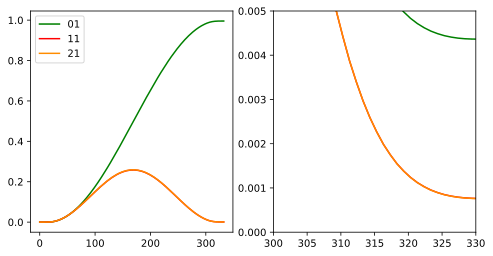

In [6]:
colors = ['green','red','darkorange']
fig,axes = plt.subplots(1,2,figsize = (8,4))
for ql in range(3):
    for tl in [1]:
        i = ql*4+tl
        axes[0].plot(tlist,results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])
        axes[1].plot(tlist,results[ql].expect[i] if not (ql == 0 and tl ==1)  else 1- results[ql].expect[i],label = f"{ql}{tl}",color = colors[ql])

axes[0].legend()
axes[1].set_ylim(0,0.005)
axes[1].set_xlim(300,330)

In [22]:
import jax.numpy as jnp
from jax import value_and_grad,grad
import jax

driven_op=system.truncate_function(system.hilbertspace.op_in_dressed_eigenbasis(system.tune_tmon.n_operator))
pulse_shape_func=square_pulse_with_rise_fall

def objective(params):
    amp_with_2pi = params[0]
    pulse_length = params[1]

    
    t_rise = 30
    t_tot = t_rise + pulse_length

    tlist = jnp.linspace(0,t_tot,int(t_tot))

    pulse_shape_args={
        'w_d': w_d,
        'amp': amp_with_2pi/(2*np.pi),
        't_rise': t_rise,
        't_square': pulse_length - t_rise
    }          

    def _H(t):
        _H =  jnp.array(system.diag_dressed_hamiltonian)
        _H += jnp.array(driven_op)* pulse_shape_func(t, pulse_shape_args)
        return _H 
    H =  timecallable(_H)

    result0 = dq.sesolve(
                H = H,
                psi0 = jnp.array(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,0)]))),
                tsave = tlist,
                solver = dq.solver.Tsit5(
                        rtol= 1e-06,
                        atol= 1e-06,
                        safety_factor= 0.9,
                        min_factor= 0.2,
                        max_factor = 5.0,
                        max_steps = int(1e4*(tlist[-1]-tlist[0])),
                    )
                )
    result1 = dq.sesolve(
                H = H,
                psi0 = jnp.array(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,0)]))),
                tsave = tlist,
                solver = dq.solver.Tsit5(
                        rtol= 1e-06,
                        atol= 1e-06,
                        safety_factor= 0.9,
                        min_factor= 0.2,
                        max_factor = 5.0,
                        max_steps = int(1e4*(tlist[-1]-tlist[0])),
                    )
                )
    result2 = dq.sesolve(
                H = H,
                psi0 =jnp.array(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,0)]))),
                tsave = tlist,
                solver = dq.solver.Tsit5(
                        rtol= 1e-06,
                        atol= 1e-06,
                        safety_factor= 0.9,
                        min_factor= 0.2,
                        max_factor = 5.0,
                        max_steps = int(1e4*(tlist[-1]-tlist[0])),
                    )
                )
    return 1 - dq.expect(qutip.ket2dm(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(0,1)]))), result0.states[-1]).real +\
          dq.expect(qutip.ket2dm(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(1,1)]))), result1.states[-1]).real +\
              dq.expect(qutip.ket2dm(system.truncate_function(qutip.basis(system.hilbertspace.dimension, system.product_to_dressed[(2,1)]))), result2.states[-1]).real




In [23]:
import optax

amp_with_2pi = 0.011026707187734986
pulse_length = 308.37376398206834-6
flux = 0.40367803977430805

optimizer = optax.adam(learning_rate=0.01) 
params = jnp.array([amp_with_2pi, pulse_length, flux])
opt_state = optimizer.init(params)

num_steps = 1000



import warnings

warnings.filterwarnings("ignore")

for step in range(num_steps):
    population_value, grads = jax.value_and_grad (objective)(params)
    print(f"Population={population_value:.4f} grads: {grads}")
    
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    amp_with_2pi, pulse_length = params


print(f'Optimized amp_with_2pi: {amp_with_2pi:.2f}')
print(f'Optimized pulse_length: {pulse_length:.2f}')

ValueError: Invalid Interaction Term. Exception: The numpy.ndarray conversion method __array__() was called on traced array with shape float64[].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerArrayConversionError